In [ ]:
#Import libraries
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [ ]:
#Load data
X_train = pd.read_csv("../data/model_input/X_train.csv")
X_test = pd.read_csv("../data/model_input/X_test.csv")

y_train = pd.read_csv("../data/model_input/y_train.csv").squeeze()
y_test = pd.read_csv("../data/model_input/y_test.csv").squeeze()

In [3]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2400, 38)
(600, 38)
(2400,)
(600,)


In [4]:
#Encoding the target labels
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

In [ ]:
#Checking the mapping
label_mapping = dict(
    zip(
        label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_)
    )
)

print(label_mapping)

{'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


In [ ]:
#Saving the encoder
joblib.dump(
    label_encoder,
    "../models/label_encoder.pkl"
)

['../models/label_encoder.pkl']

In [ ]:
#Creating the base XGBoost model
xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

In [ ]:
#Define a small tuning grid
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

In [9]:
#Configure GridSearchCV
grid_search_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

In [10]:
#The tuning
grid_search_xgb.fit(X_train,y_train_encoded)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier..._class=3, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will 

In [11]:
#The best settings
print("Best Parameters:")
print(grid_search_xgb.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(grid_search_xgb.best_score_)

Best Parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}

Best Cross-Validation F1 Score:
0.8739910887959128


In [ ]:
#The best model
best_xgb_model = grid_search_xgb.best_estimator_

In [ ]:
#Checking the training and testing accuracy
train_accuracy = best_xgb_model.score(
    X_train,
    y_train_encoded
)

test_accuracy = best_xgb_model.score(
    X_test,
    y_test_encoded
)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 1.0
Testing Accuracy: 0.85


In [ ]:
#Making predictions
y_pred_encoded = best_xgb_model.predict(X_test)

In [ ]:
#Converting predictions back to words
y_pred = label_encoder.inverse_transform(
    y_pred_encoded
)

In [ ]:
#Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.85
Precision: 0.8497680405495531
Recall   : 0.85
F1 Score : 0.849841199590828


In [ ]:
#Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.87      0.89      0.88       200
         Low       0.90      0.89      0.90       202
      Medium       0.78      0.77      0.77       198

    accuracy                           0.85       600
   macro avg       0.85      0.85      0.85       600
weighted avg       0.85      0.85      0.85       600



In [18]:
#Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[178   0  22]
 [  0 180  22]
 [ 26  20 152]]


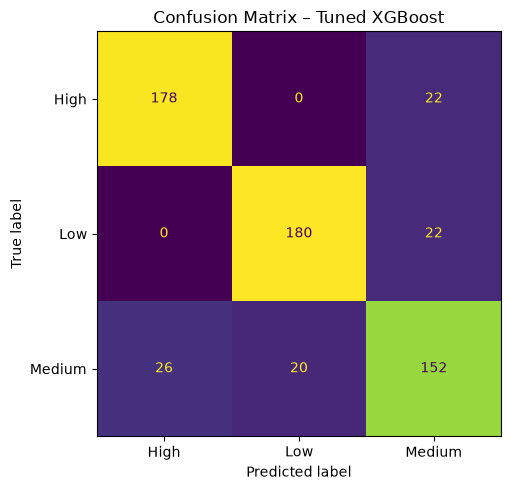

In [19]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=label_encoder.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(6, 5))

disp.plot(
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix – Tuned XGBoost")
plt.tight_layout()
plt.show()

In [ ]:
#Feature importance
feature_importance_xgb = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_xgb_model.feature_importances_
})

feature_importance_xgb = feature_importance_xgb.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_xgb.head(15)

,Feature,Importance
7,bacteria_count,0.247171
9,infant_mortality_rate,0.077999
1,contaminant_level,0.060189
3,turbidity,0.048767
13,sanitation_coverage,0.045178
10,gdp_per_capita,0.034664
8,clean_water_access,0.031054
11,healthcare_access,0.025135
6,lead,0.024639
5,nitrate,0.022538


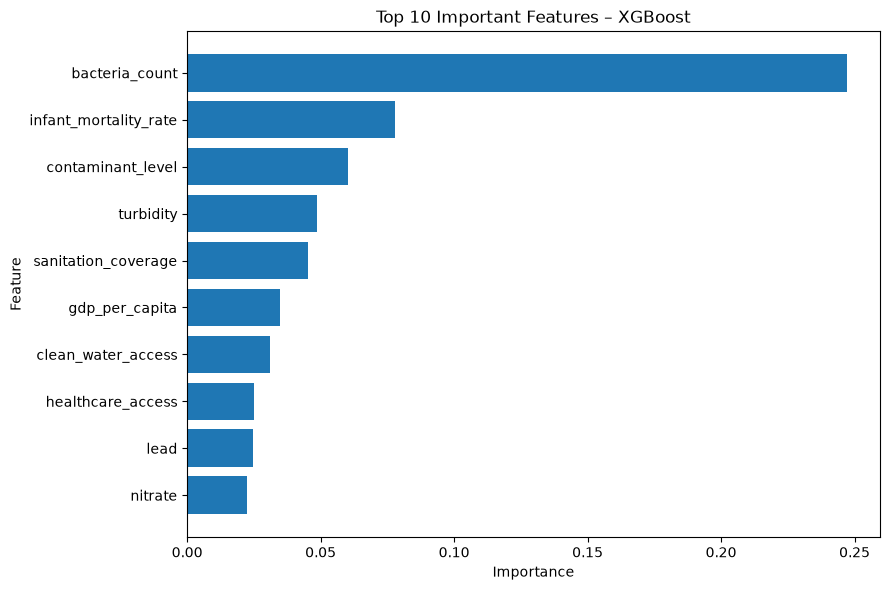

In [ ]:
#Plot for the top 10 features
top_features_xgb = feature_importance_xgb.head(10)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features_xgb["Feature"],
    top_features_xgb["Importance"]
)

plt.title("Top 10 Important Features – XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
#The results table
results_xgb = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Accuracy",
        "Cross-Validation F1"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        train_accuracy,
        grid_search_xgb.best_score_
    ]
})

results_xgb

,Metric,Value
0,Accuracy,0.850000
1,Precision,0.849768
2,Recall,0.850000
3,F1 Score,0.849841
4,Training Accuracy,1.000000
5,Cross-Validation F1,0.873991


In [ ]:
#Model saving
joblib.dump(
    best_xgb_model,
    "../models/xgboost_tuned.pkl"
)

['../models/xgboost_tuned.pkl']

In [ ]:
#Saving the tuning results
cv_results_xgb = pd.DataFrame(
    grid_search_xgb.cv_results_
)

cv_results_xgb.to_csv(
    "../reports/tables/xgboost_grid_search_results.csv",
    index=False
)